# 모델 분할 전략 × 용량 × 계열 — 93의 미해결 닫기

수치 원본은 같은 폴더의 [`RESULTS.md`](./RESULTS.md)이고, 어긋나면 그쪽이 맞다.

**용어**: *모델 분할*(학습 단위를 호선·군집·시리즈로 쪼갬) ↔ *전역 모델*(쪼개지 않음) ↔
*데이터 분할*(2024/2025 시간 경계). 이 노트북에서 "분할"은 항상 앞의 것이다.

93은 분할 모델에도 전역에서 고른 용량(`num_leaves 31 · 300그루`)을 그대로 써서, 6호선 −2.98%p가
**분할 탓인지 용량 탓인지** 구분하지 못했다. 여기서 용량 축을 더해 그 둘을 가른다.

In [1]:
import sys
from pathlib import Path

AI_ROOT = Path.cwd()
while not (AI_ROOT / "app" / "CROWD").exists():
    AI_ROOT = AI_ROOT.parent
sys.path.insert(0, str(AI_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle

figstyle.apply(inline=True)

VAL = AI_ROOT / "data" / "CROWD" / "interim" / "validation" / "split_tuning_check"
a = pd.read_parquet(VAL / "split_tuning_A_격자.parquet")
c = pd.read_parquet(VAL / "split_tuning_C_전역_대비_쌍차이.parquet")

SPLITS = ["global", "line", "cluster", "line6"]
PARAMS = ["p15_150", "p31_300", "p63_600"]
LADDER = ["global", "line", "cluster", "series"]
TARGETS = ["boarding", "alighting"]
KOR = {"boarding": "승차", "alighting": "하차"}
tot = a[a["axis"] == "전체"]

print(f"격자 {tot[tot['계열'] == 'lightgbm']['run'].nunique()}칸 · "
      f"선형 사다리 {tot[tot['계열'] == 'linear']['run'].nunique()}단")
print("재현 게이트 global|p31_300:",
      tot[(tot.run == "global|p31_300")].set_index("target")["RMSE_개선율_%"].round(2).to_dict())

격자 12칸 · 선형 사다리 4단
재현 게이트 global|p31_300: {'boarding': 23.38, 'alighting': 25.36}


## 1. 분할 × 용량 — 부호가 용량에 따라 바뀐다

전역은 `p31_300`(90 채택)이 최적이고, **호선별은 용량을 줄이면 전역을 넘는다**. 군집별은 어느
용량에서도 전역보다 낫고, 용량을 키우면 모든 분할이 무너진다.

파라미터      p15_150            p31_300            p63_600         
target  alighting boarding alighting boarding alighting boarding
분할                                                              
global      25.15    22.98     25.36    23.38     24.66    22.96
line        25.50    23.73     25.14    23.09     23.35    21.92
cluster     26.16    24.11     26.08    23.94     25.07    23.37
line6       25.29    23.24     25.41    23.18     24.59    22.32


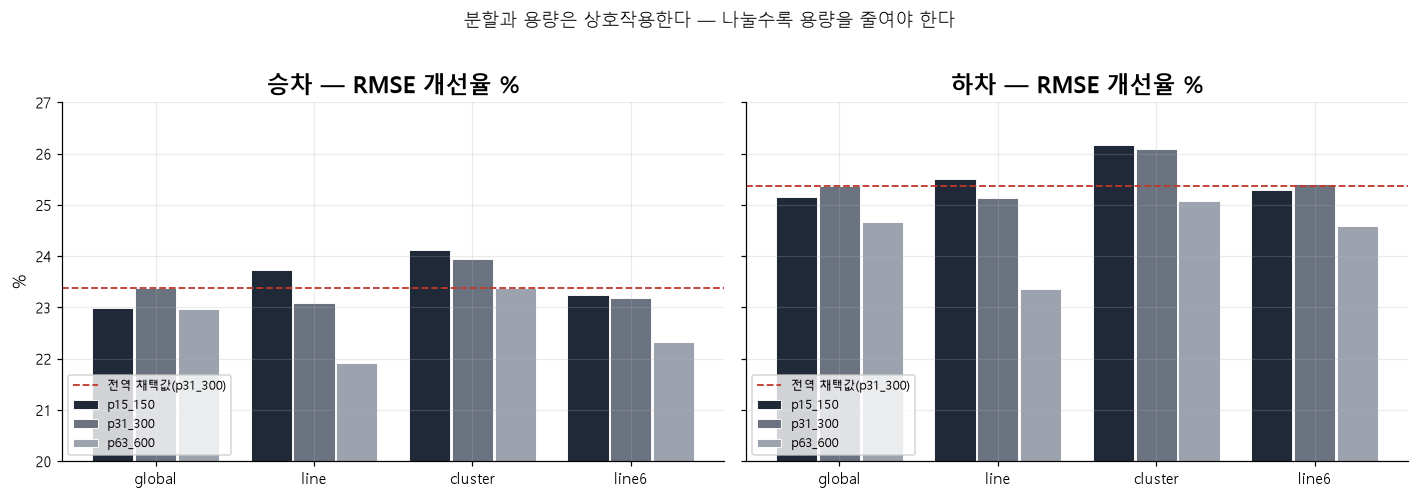

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
xx = np.arange(len(SPLITS))
for ax, t in zip(axes, TARGETS):
    sub = tot[(tot["계열"] == "lightgbm") & (tot["target"] == t)]
    piv = sub.pivot_table(index="분할", columns="파라미터", values="RMSE_개선율_%").reindex(SPLITS)
    base = piv.loc["global", "p31_300"]
    for i, p in enumerate(PARAMS):
        ax.bar(xx + (i - 1) * 0.27, piv[p].to_numpy(), 0.26, label=p,
               color=figstyle.PALETTE_NEUTRAL[i], edgecolor="white", linewidth=0.6)
    ax.axhline(base, color="#C0392B", linewidth=1.2, linestyle="--",
               label="전역 채택값(p31_300)")
    ax.set_xticks(xx)
    ax.set_xticklabels(SPLITS)
    ax.set_ylim(20, 27)
    ax.set_title(f"{KOR[t]} — RMSE 개선율 %")
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("%")
fig.suptitle("분할과 용량은 상호작용한다 — 나눌수록 용량을 줄여야 한다", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "split_tuning_grid")

print(tot[(tot["계열"] == "lightgbm")].pivot_table(
    index="분할", columns=["파라미터", "target"], values="RMSE_개선율_%"
).reindex(SPLITS).round(2).to_string())

## 2. 6호선 — 용량으로 절반만 설명된다

93이 지목한 호선이다. 호선별 분할의 손실이 `p31_300` −4.42%p → `p15_150` −2.25%p로 줄지만 남는다
→ "6호선의 약점은 데이터 부족이 아니라 규칙성 부족"이라는 93의 진단이 유지된다.

파라미터     p15_150  p31_300  p63_600
분할                                
global     11.10    11.04     9.45
line        8.79     6.62     4.27
cluster    10.74     9.64     7.44
line6       8.79     6.62     4.27


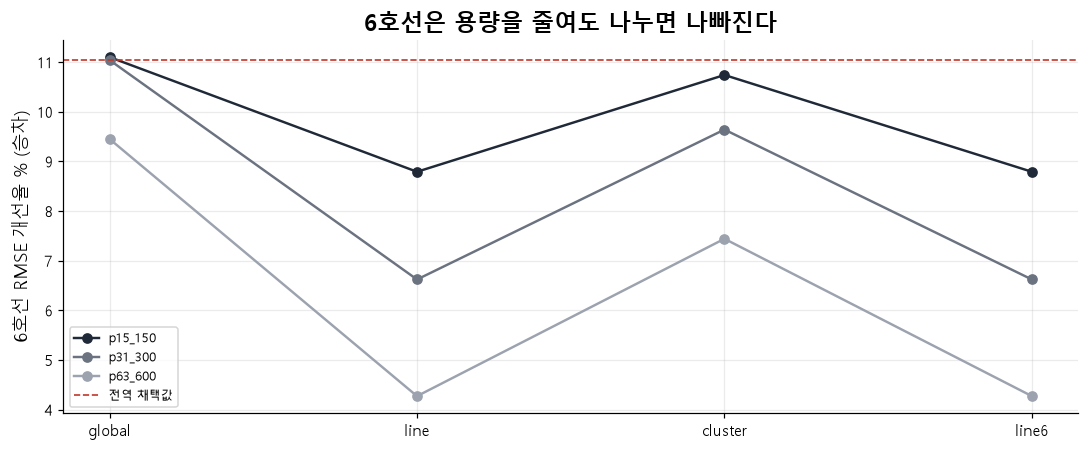

In [3]:
six = a[(a["axis"] == "line") & (a["group"] == "6호선")
        & (a["target"] == "boarding") & (a["계열"] == "lightgbm")]
piv6 = six.pivot_table(index="분할", columns="파라미터", values="RMSE_개선율_%").reindex(SPLITS)

fig, ax = plt.subplots(figsize=(10, 4.2))
for i, p in enumerate(PARAMS):
    ax.plot(SPLITS, piv6[p].to_numpy(), marker="o", linewidth=1.6,
            color=figstyle.PALETTE_NEUTRAL[i], label=p)
ax.axhline(piv6.loc["global", "p31_300"], color="#C0392B", linestyle="--", linewidth=1.1,
           label="전역 채택값")
ax.set_ylabel("6호선 RMSE 개선율 % (승차)")
ax.set_title("6호선은 용량을 줄여도 나누면 나빠진다")
ax.legend(fontsize=8)
fig.tight_layout()
_ = figstyle.save(fig, "split_tuning_line6")

print(piv6.round(2).to_string())

## 3. 전역 대비 쌍 부트스트랩 — 군집별만 CI 하한이 0 위

점추정으로 1%p 문턱을 보면 93처럼 전부 기각이지만, 같은 재표본에서 짝을 지어 구간을 붙이면
**군집별은 RMSE·MAE 넷 다 유의한 개선**이다(+0.25~+0.50%p 하한).

                          point_diff_RMSE_%p(계열-LightGBM)  diff_RMSE_CI_low  diff_RMSE_CI_high
series         target                                                                         
line           alighting                            -0.20             -0.49               0.05
cluster        alighting                             0.70              0.50               0.91
line6          alighting                             0.03             -0.14               0.19
linear_global  alighting                            -2.84             -3.70              -1.98
linear_line    alighting                            -2.59             -3.42              -1.73
linear_cluster alighting                            -2.48             -3.36              -1.55
linear_series  alighting                             0.30             -0.57               1.12
line           boarding                             -0.24             -0.57               0.06
cluster        boarding                           

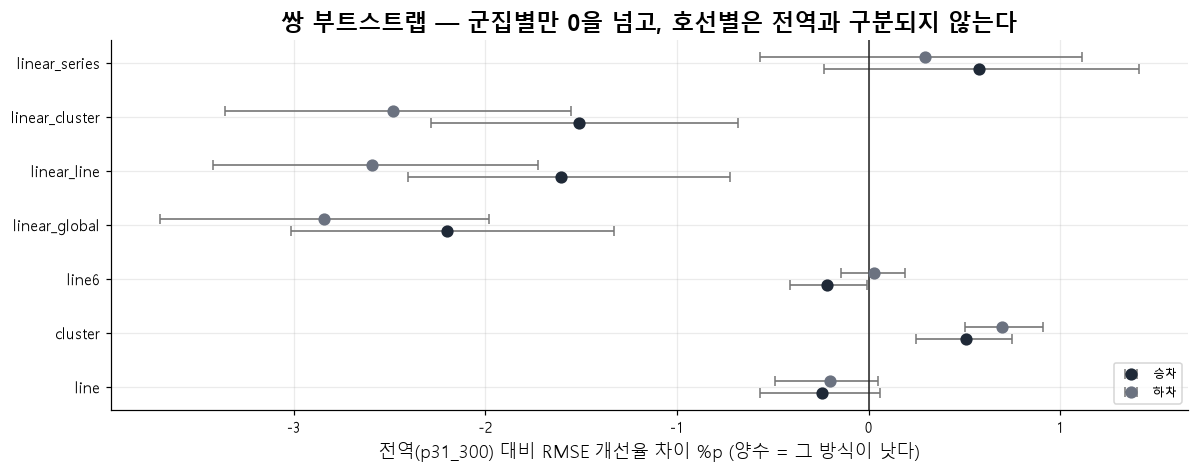

In [4]:
DIFF_R = "point_diff_RMSE_%p(계열-LightGBM)"
ORDER = ["line", "cluster", "line6", "linear_global", "linear_line", "linear_cluster",
         "linear_series"]
ctot = c[c["axis"] == "전체"]

fig, ax = plt.subplots(figsize=(11, 4.4))
yy = np.arange(len(ORDER))
for i, t in enumerate(TARGETS):
    part = ctot[ctot["target"] == t].set_index("series").reindex(ORDER)
    point = part[DIFF_R].to_numpy()
    lo = point - part["diff_RMSE_CI_low"].to_numpy()
    hi = part["diff_RMSE_CI_high"].to_numpy() - point
    ax.errorbar(point, yy + (i - 0.5) * 0.22, xerr=[lo, hi], fmt="o", markersize=7,
                capsize=3, color=figstyle.PALETTE_NEUTRAL[i], ecolor="#777",
                elinewidth=1.1, label=KOR[t])
ax.axvline(0, color="#222", linewidth=1.0)
ax.set_yticks(yy)
ax.set_yticklabels(ORDER)
ax.set_xlabel("전역(p31_300) 대비 RMSE 개선율 차이 %p (양수 = 그 방식이 낫다)")
ax.set_title("쌍 부트스트랩 — 군집별만 0을 넘고, 호선별은 전역과 구분되지 않는다")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
_ = figstyle.save(fig, "split_tuning_paired")

print(ctot.set_index(["series", "target"])[
    [DIFF_R, "diff_RMSE_CI_low", "diff_RMSE_CI_high"]
].round(2).to_string())

## 4. 계열마다 분할의 답이 다르다

선형 계열은 분할이 **단조롭게** 이득이고 대부분이 마지막 단계(역×시간대별 5,460모델)에서 나온다.
LightGBM은 `station_no`·`time_slot`을 범주 피처로 이미 갖고 있어 그 이질성을 모델 안에서 흡수한다 —
그래서 쪼개는 이득이 작다.

target   alighting  boarding
분할                          
global       23.28     22.02
line         23.53     22.61
cluster      23.64     22.70
series       26.39     24.77


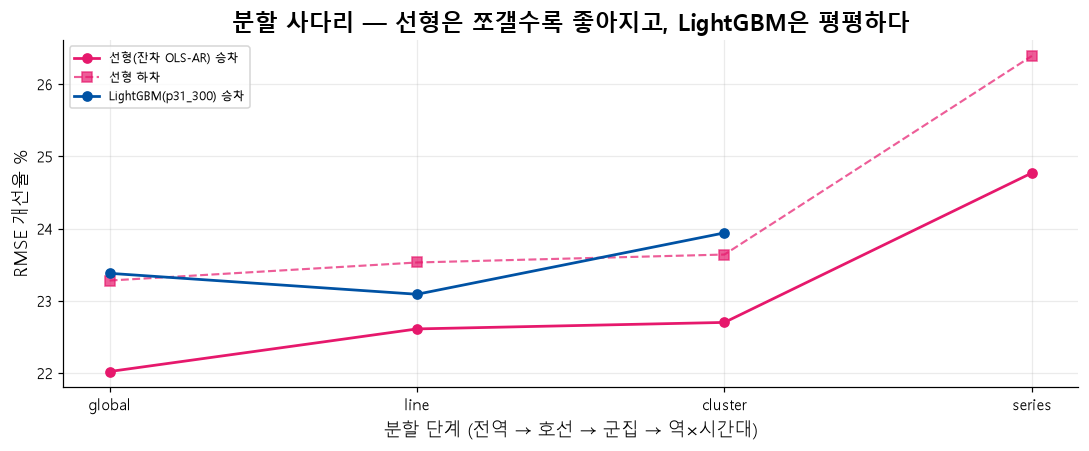

In [5]:
lin = tot[tot["계열"] == "linear"].pivot_table(
    index="분할", columns="target", values="RMSE_개선율_%"
).reindex(LADDER)
lgb = tot[(tot["계열"] == "lightgbm") & (tot["파라미터"] == "p31_300")].pivot_table(
    index="분할", columns="target", values="RMSE_개선율_%"
).reindex(["global", "line", "cluster"])

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(LADDER, lin["boarding"].to_numpy(), marker="o", linewidth=1.8,
        color=figstyle.COLOR_ACCENT, label="선형(잔차 OLS-AR) 승차")
ax.plot(LADDER, lin["alighting"].to_numpy(), marker="s", linewidth=1.4, linestyle="--",
        color=figstyle.COLOR_ACCENT, alpha=0.7, label="선형 하차")
ax.plot(["global", "line", "cluster"], lgb["boarding"].to_numpy(), marker="o", linewidth=1.8,
        color=figstyle.COLOR_MODEL, label="LightGBM(p31_300) 승차")
ax.set_ylabel("RMSE 개선율 %")
ax.set_xlabel("분할 단계 (전역 → 호선 → 군집 → 역×시간대)")
ax.set_title("분할 사다리 — 선형은 쪼갤수록 좋아지고, LightGBM은 평평하다")
ax.legend(fontsize=8)
fig.tight_layout()
_ = figstyle.save(fig, "split_tuning_ladder")

print(lin.round(2).to_string())

## 5. 읽은 것

1. **93의 "호선별은 이득 없음"은 "전역 용량 그대로 나누면 이득 없음"이 정확한 진술이다.** 용량을
   줄이면(`p15_150`) 전체는 +0.35%p로 부호가 바뀐다. 다만 전역과 CI로 구분되지 않고 6호선 −2.25%p가
   남아 판정(기각)은 유지된다.
2. **군집별 분할은 재검토 대상으로 올라간다.** 쌍 부트스트랩에서 RMSE·MAE 넷 다 CI 하한이 0 위
   (+0.25~+0.50%p)이고 `p15_150`에서는 +0.73/+0.80%p다. 이득의 대부분은 1호선(+2.59%p)에서 나온다.
3. **6호선은 어떤 용량에서도 나누면 나빠진다** — 데이터 부족이 아니라 규칙성 부족이라는 93 진단 유지.
   군집별을 채택하려면 6호선만 전역으로 빼는 하이브리드가 필요하다.
4. **계열이 분할의 답을 바꾼다.** 선형은 시리즈별까지 쪼개면 +2.75%p, LightGBM은 범주 피처가 그 일을
   이미 해서 평평하다. "분할이 효과적인가"는 계열을 빼고는 답할 수 없는 질문이었다.
5. **용량은 분할과 함께 움직여야 한다** — `p63_600`에서는 모든 분할이 전역보다 나쁘다.